<a href="https://colab.research.google.com/github/munhyunsik/ML/blob/ML/week10_report.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<ipython-input-10-ceb8e020e2bf>:73: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  W1[0][0] += -alpha * dJdW1_11
<ipython-input-10-ceb8e020e2bf>:74: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  W1[0][1] += -alpha * dJdW1_12
<ipython-input-10-ceb8e020e2bf>:75: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  W1[1][0] += -alpha * dJdW1_21
<ipython-input-10-ceb8e020e2bf>:76: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will erro

MSE and MAPE at epoch  0  : 0.4923692081588331  , 641.2237701880406
MSE and MAPE at epoch  5  : 0.022246601021031175  , 107.66956507883877
MSE and MAPE at epoch  10  : 0.0010939950284458314  , 6.327061349178779
MSE and MAPE at epoch  15  : 0.0009431841058067317  , 6.289273870287084
MSE and MAPE at epoch  20  : 0.000879499477765787  , 6.363546602574931
MSE and MAPE at epoch  25  : 0.0008454180822275695  , 6.422813654178073
MSE and MAPE at epoch  30  : 0.0008243076834218878  , 6.466028368064743
MSE and MAPE at epoch  35  : 0.0008091300290140491  , 6.569256908978918
MSE and MAPE at epoch  40  : 0.0007967970084727224  , 6.720565021532787
MSE and MAPE at epoch  45  : 0.0007859123333003955  , 6.823595534615884
MSE and MAPE at epoch  49  : 0.0007777988486311408  , 6.875034849438898


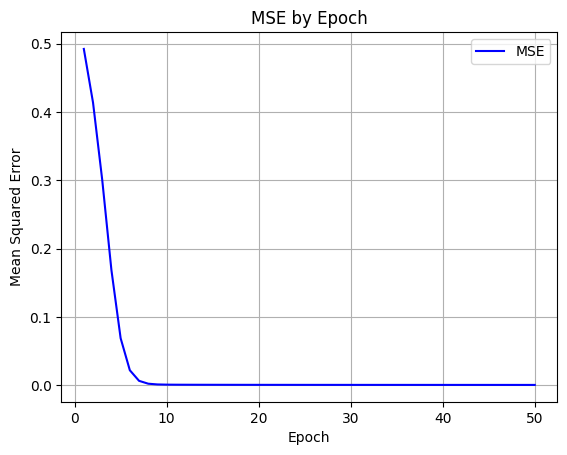

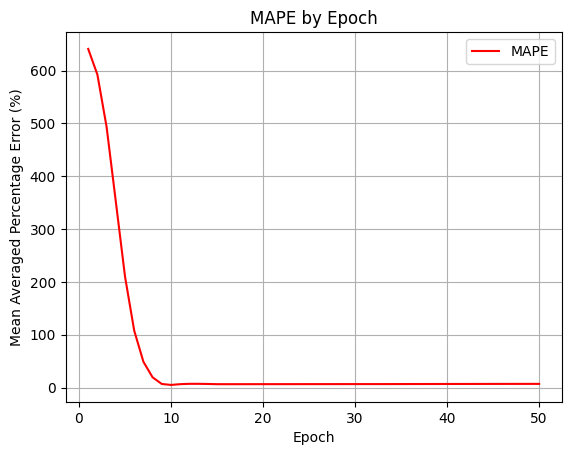

In [10]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
samples = 1000

x1 = np.random.uniform(0, 1, samples)
x2 = np.random.uniform(0, 1, samples)

Input = np.column_stack((x1, x2))

y = 2 * x1 + 3 * x2 - 1

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return sigmoid(x) * (1 - sigmoid(x))

input_layer_size = 2
hidden_layer_size = 3
output_layer_size = 1

W1 = np.random.rand(hidden_layer_size, input_layer_size)
b1 = np.random.rand(hidden_layer_size)
W2 = np.random.rand(output_layer_size, hidden_layer_size)
b2 = np.random.rand(output_layer_size)

alpha = 0.01
epochs = 50

MSE_list, MAPE_list = [], []
for epoch in range(epochs):
    MSE, MAPE = 0, 0
    for iter in range(samples):
        X = Input[iter]

        # Feedforward
        Z_tilde = W1 @ X.reshape(-1, 1) + b1.reshape(-1, 1)
        Z = sigmoid(Z_tilde)
        y_pred = W2 @ Z + b2.reshape(-1, 1)

        # Loss
        J = 0.5 * (y_pred - y[iter]) ** 2
        MSE += J
        MAPE += np.abs((y_pred - y[iter]) / y[iter]) * 100

        # Backpropagation
        # Output layer --> Hidden layer
        dJdY = (y_pred - y[iter])
        dJdW2_11 = dJdY * Z[0]
        dJdW2_12 = dJdY * Z[1]
        dJdW2_13 = dJdY * Z[2]
        dJdb2_1 = dJdY

        dJdZ1 = dJdY * W2[0][0]
        dJdZ2 = dJdY * W2[0][1]
        dJdZ3 = dJdY * W2[0][2]

        # Hidden layer --> Input layer
        dJdW1_11 = dJdZ1 * X[0] * sigmoid_derivative(Z_tilde[0])
        dJdW1_12 = dJdZ1 * X[1] * sigmoid_derivative(Z_tilde[0])
        dJdW1_21 = dJdZ2 * X[0] * sigmoid_derivative(Z_tilde[1])
        dJdW1_22 = dJdZ2 * X[1] * sigmoid_derivative(Z_tilde[1])
        dJdW1_31 = dJdZ3 * X[0] * sigmoid_derivative(Z_tilde[2])
        dJdW1_32 = dJdZ3 * X[1] * sigmoid_derivative(Z_tilde[2])

        dJdb1_1 = dJdZ1 * sigmoid_derivative(Z_tilde[0])
        dJdb1_2 = dJdZ2 * sigmoid_derivative(Z_tilde[1])
        dJdb1_3 = dJdZ3 * sigmoid_derivative(Z_tilde[2])

        # Update
        W1[0][0] += -alpha * dJdW1_11
        W1[0][1] += -alpha * dJdW1_12
        W1[1][0] += -alpha * dJdW1_21
        W1[1][1] += -alpha * dJdW1_22
        W1[2][0] += -alpha * dJdW1_31
        W1[2][1] += -alpha * dJdW1_32

        b1[0] += -alpha * dJdb1_1
        b1[1] += -alpha * dJdb1_2
        b1[2] += -alpha * dJdb1_3

        W2[0][0] += -alpha * dJdW2_11
        W2[0][1] += -alpha * dJdW2_12
        W2[0][2] += -alpha * dJdW2_13
        b2[0] += -alpha * dJdb2_1

    MSE /= samples
    MAPE /= samples
    MSE_list.append(np.squeeze(MSE))
    MAPE_list.append(np.squeeze(MAPE))
    if epoch % 5 == 0 or epoch == epochs - 1:
      print('MSE and MAPE at epoch ', epoch, ' :', np.squeeze(MSE), ' ,', np.squeeze(MAPE))

plt.figure()
plt.plot(np.arange(1, epochs+1), MSE_list, label='MSE', color='b')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.title('MSE by Epoch')
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(np.arange(1, epochs+1), MAPE_list, label='MAPE', color='r')
plt.xlabel('Epoch')
plt.ylabel('Mean Averaged Percentage Error (%)')
plt.title('MAPE by Epoch')
plt.legend()
plt.grid(True)
plt.show()
